In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tracking_data = pd.read_csv("results.csv")

#write name of color to analyze (yellow, green, red)
color = "green"

X_COLOR_1 = f"{color}_x1"
X_COLOR_2 = f"{color}_x2"
Y_COLOR_1 = f"{color}_y1"
Y_COLOR_2 = f"{color}_y2"
A_COLOR_1 = f"{color}_area1"
A_COLOR_2 = f"{color}_area2"
X_CENTER = "center_x"
Y_CENTER = "center_y"



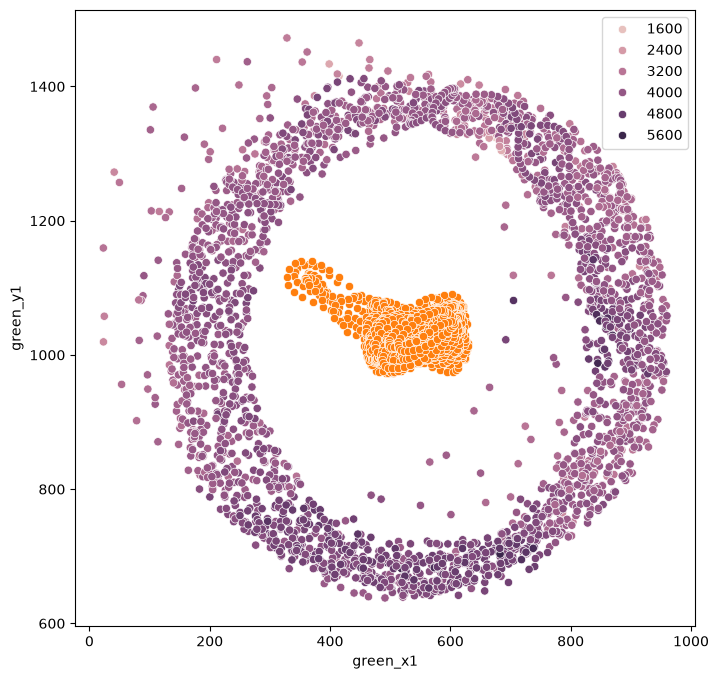

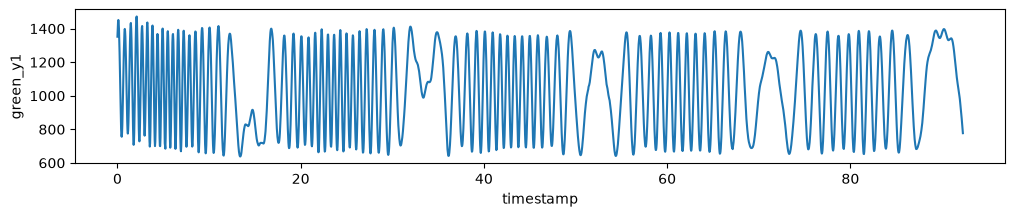

<Figure size 800x800 with 0 Axes>

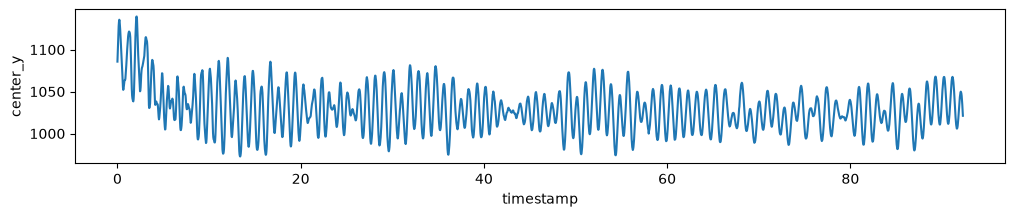

In [46]:
#Time series data

#TODO: incorperate the time data into the scatter plots so we can visualize the trajectory
#TODO: highlight regions with low/high area

plt.figure(figsize=(8,8))
sns.scatterplot(tracking_data, x=X_COLOR_1, y=Y_COLOR_1, hue=A_COLOR_1)
sns.scatterplot(tracking_data, x=X_CENTER, y=Y_CENTER)
#sns.lineplot(tracking_data, x=X_COLOR_1, y=Y_COLOR_1, lw=0.2)

plt.figure(figsize=(12,2))
sns.lineplot(tracking_data, x="timestamp", y=Y_COLOR_1)

plt.figure(figsize=(8,8))

plt.figure(figsize=(12,2))
sns.lineplot(tracking_data, x="timestamp", y=Y_CENTER)

plt.show()

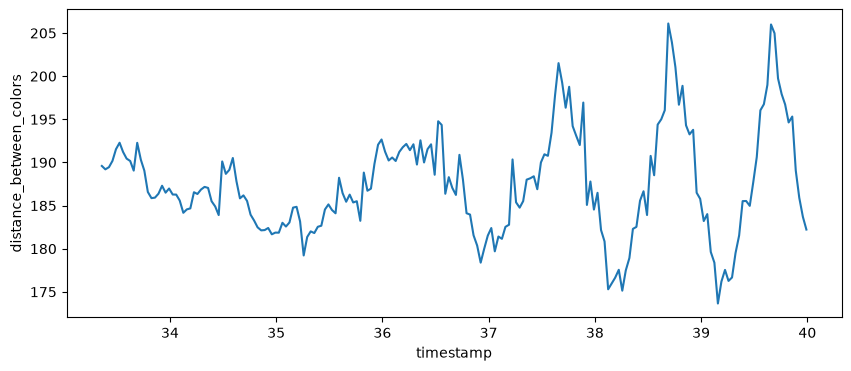

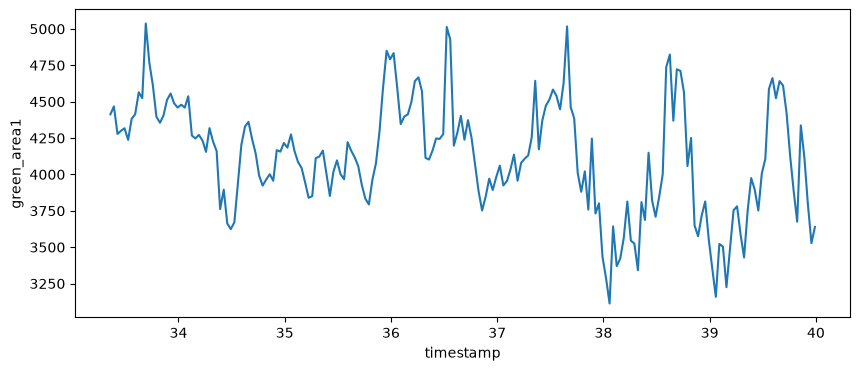

In [32]:
# Looking at how the distance between adjacent dots changes over time
import numpy as np 

tracking_data["distance_between_colors"] = np.hypot(
    abs(tracking_data[X_COLOR_1] - tracking_data[X_COLOR_2]),
    abs(tracking_data[Y_COLOR_1] - tracking_data[Y_COLOR_2])
)

plt.figure(figsize=(10, 4))
sns.lineplot(tracking_data[1000:1200], x="timestamp", y="distance_between_colors")

plt.figure(figsize=(10, 4))
sns.lineplot(tracking_data[1000:1200], x="timestamp", y=A_COLOR_1)

plt.show()


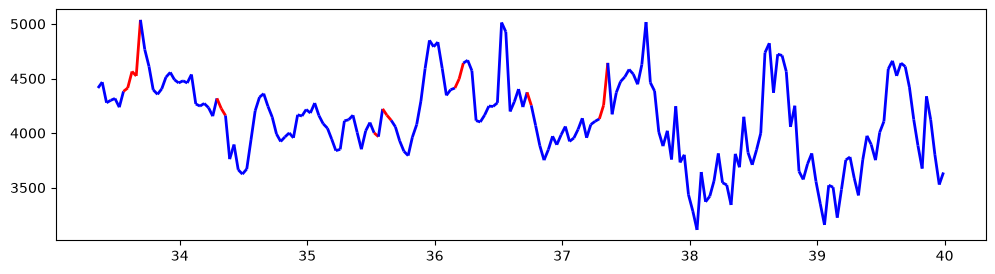

In [33]:
#Looking at whether area fluctuations are due to lighting or clipping with the edge

from matplotlib.collections import LineCollection

x = tracking_data["timestamp"].values
y = tracking_data[A_COLOR_1].values

LOWER_BOUND = 0
UPPER_BOUND = 100

tracking_data["near_edge"] = (
    (tracking_data[X_COLOR_1] > LOWER_BOUND) &
    (tracking_data[X_COLOR_1] < UPPER_BOUND)
)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[1000:1199], points[1001:1200]], axis=1)
colors = np.where(tracking_data["near_edge"].iloc[:-1], "red", "blue")

lc = LineCollection(
    segments, # type: ignore
    colors=colors,
    linewidths=2
)

fig, ax = plt.subplots(figsize=(12,3))
ax.add_collection(lc)
ax.autoscale()

plt.show()

<Axes: xlabel='timestamp', ylabel='distance_center'>

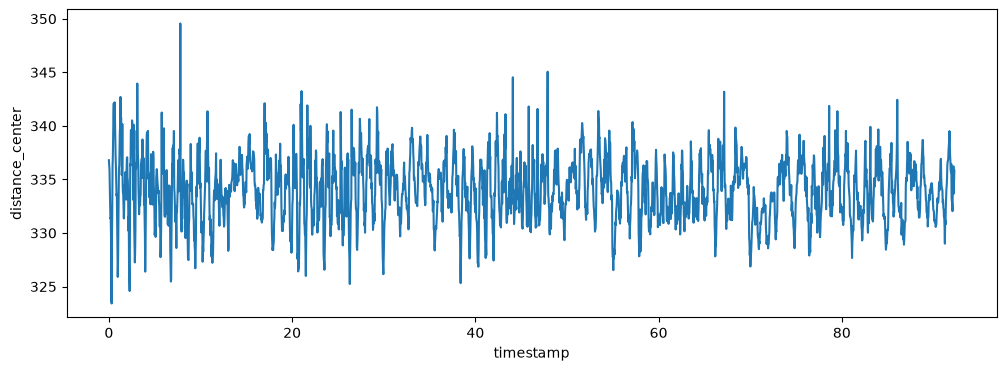

In [34]:
# Dist to Center

tracking_data["distance_center"] = np.hypot(
    abs(tracking_data[X_COLOR_1] - tracking_data[X_CENTER]),
    abs(tracking_data[Y_COLOR_1] - tracking_data[Y_CENTER])
)

plt.figure(figsize=(12, 4))
sns.lineplot(tracking_data, x="timestamp", y="distance_center")

63   -1103.200664
64   -1123.150499
65   -1141.443675
66   -1162.263905
67   -1183.250860
Name: angle, dtype: float64
63   -130.084
64   -226.755
65   -287.276
66   -301.608
67   -315.940
dtype: float64
63    303.4990
64    241.8880
65    156.3440
66     40.9725
67    -74.3990
dtype: float64
Point 66: 330.014 and 63    211.437
64    105.832
65     41.176
66        NaN
67     23.359
Name: green_x1, dtype: float64


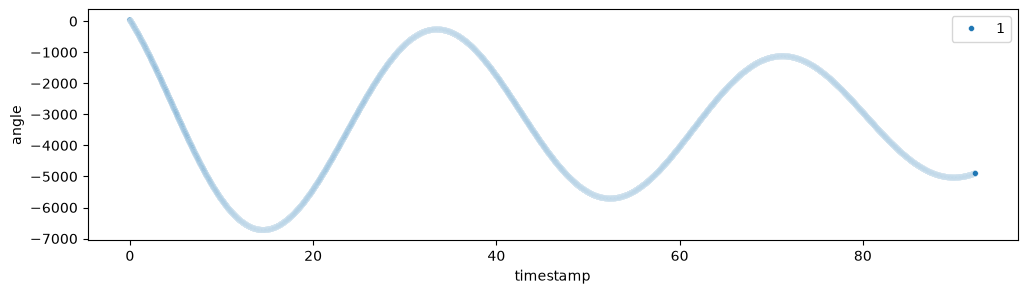

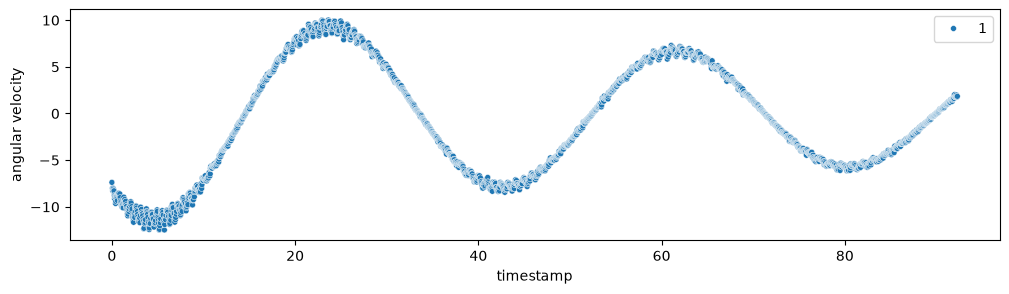

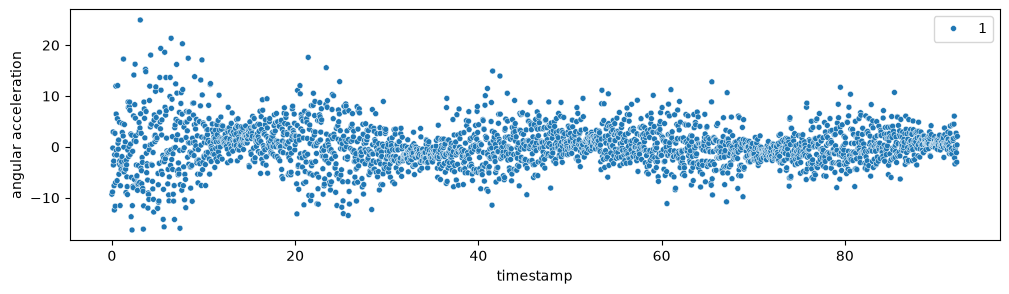

In [43]:

#Figure out why unwrapping is cutting off arbitrarily
#Plot angular velocity vs angular acceleration

dx = tracking_data[X_COLOR_1] - tracking_data[X_CENTER]
dy = tracking_data[Y_COLOR_1] - tracking_data[Y_CENTER]

dx.interpolate(inplace=True)
dy.interpolate(inplace=True)

angle = np.unwrap(np.arctan2(dx, dy))

tracking_data["angle"] = np.degrees(angle)
tracking_data["angular velocity"] = np.gradient((angle), tracking_data["timestamp"])
tracking_data["angular acceleration"] = np.gradient(tracking_data["angular velocity"], tracking_data["timestamp"])

plt.figure(figsize=(12,3))
sns.scatterplot(tracking_data[:], x="timestamp", y="angle", size=1)

plt.figure(figsize=(12,3))
sns.scatterplot(tracking_data[:], x="timestamp", y="angular velocity", size=1)

plt.figure(figsize=(12,3))
sns.scatterplot(tracking_data[:], x="timestamp", y="angular acceleration", size=1)

print(tracking_data["angle"][63:68])
print(dx[63:68])
print(dy[63:68])
print(f"Point 66: {tracking_data[X_CENTER][66]} and {tracking_data[X_COLOR_1][63:68]}")

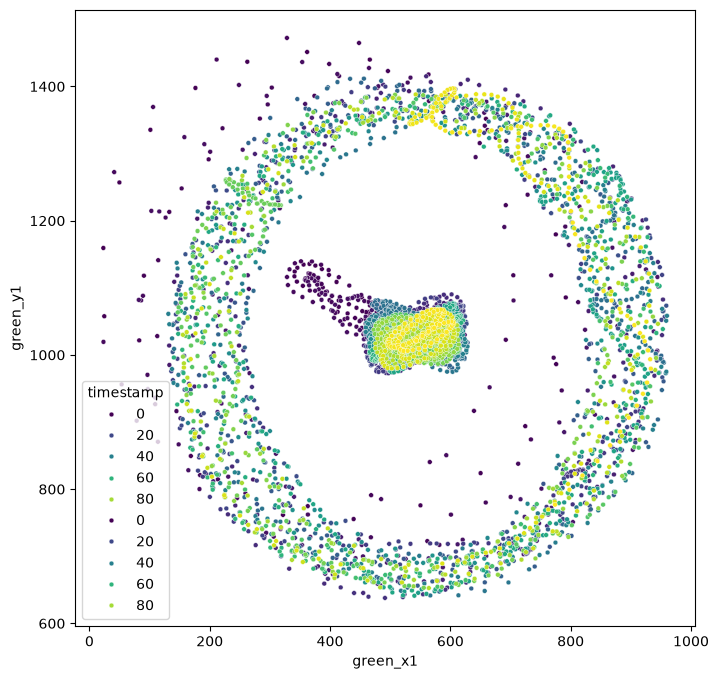

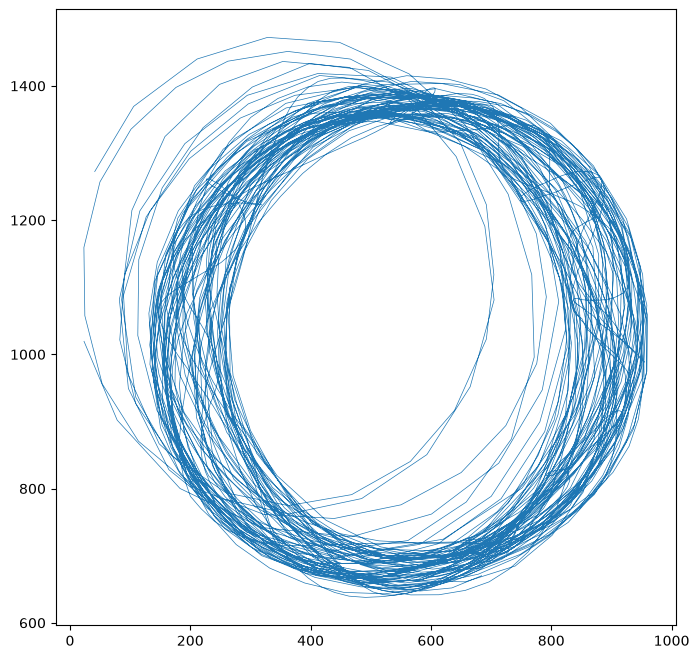

In [ ]:

plt.figure(figsize=(8,8))
sns.scatterplot(
    tracking_data,
    x=X_COLOR_1,
    y=Y_COLOR_1,
    hue="timestamp",
    palette="viridis",
    s=12
)

sns.scatterplot(
    tracking_data,
    x=X_CENTER,
    y=Y_CENTER,
    hue="timestamp",
    palette="viridis",
    s=12
)

plt.figure(figsize=(8,8))
plt.plot(
    tracking_data[X_COLOR_1],
    tracking_data[Y_COLOR_1],
    lw=0.5,
    alpha=0.6
)

plt.plot(
    tracking_data[X_CENTER]
    tracking_data[Y_CENTER],
    lw=0.5,
    alpha=0.6
)